# Notebook import

In [1]:
# from sklearn.datasets import fetch_california_housing
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

C:\Users\ryan6\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Gather Data

In [2]:
#load_boston = fetch_openml(data_id=531, as_frame=True, parser='pandas')
load_boston = fetch_openml(data_id=531)

C:\Users\ryan6\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [3]:
boston_dataset = load_boston
 
boston_dataset['data']
 
type(boston_dataset)

sklearn.utils._bunch.Bunch

## Questions to ask for exploring data:
- Source of the data
- Description of the data available? Context
- Size of the dataset
- Number of features (think of columns in a table for every row)
- Names of the features
- Nature of the features

In [4]:
dir(boston_dataset)

['DESCR',
 'categories',
 'data',
 'details',
 'feature_names',
 'frame',
 'target',
 'target_names',
 'url']

In [5]:
print(boston_dataset.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

## Datapoints and features

In [6]:
 boston_dataset.data.shape #chaining the attributes

(506, 13)

In [7]:
boston_dataset.feature_names

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [8]:
# Prices in (000)$
boston_dataset.target

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

# Data exploration with Pandas dataframe

In [9]:
#Create a dataframe
data = pd.DataFrame(data=boston_dataset.data, columns=boston_dataset.feature_names)

#Add column with price(target)
data['PRICE'] = boston_dataset.target

In [10]:
data.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


In [11]:
data.count() # No. of rows for each column

CRIM       506
ZN         506
INDUS      506
CHAS       506
NOX        506
RM         506
AGE        506
DIS        506
RAD        506
TAX        506
PTRATIO    506
B          506
LSTAT      506
PRICE      506
dtype: int64

# Cleaning data - check for missing values

In [12]:
pd.isnull(data).any()

CRIM       False
ZN         False
INDUS      False
CHAS       False
NOX        False
RM         False
AGE        False
DIS        False
RAD        False
TAX        False
PTRATIO    False
B          False
LSTAT      False
PRICE      False
dtype: bool

In [13]:
data.info()
data['CHAS'] = data['CHAS'].astype(float)
data['RAD'] = data['RAD'].astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  PRICE    506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


## Visualising Data - Histograms, Distributions and Bar Charts

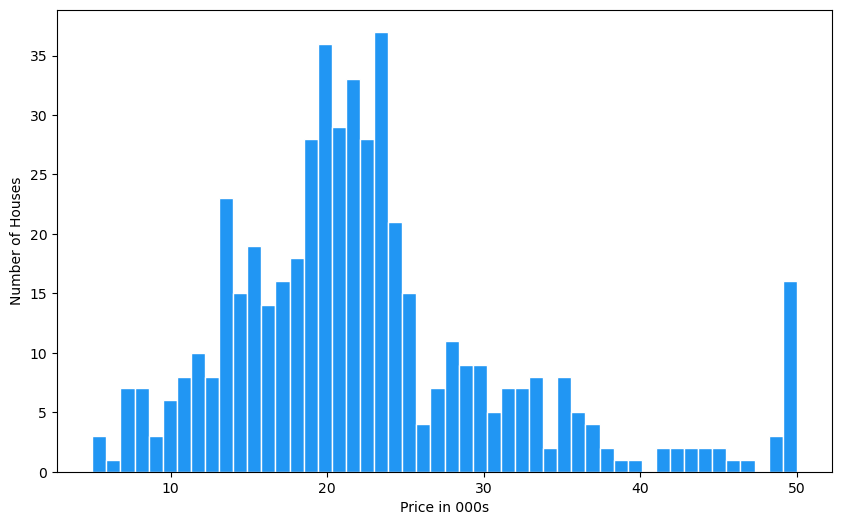

In [14]:
plt.figure(figsize=(10,6))
plt.hist(data["PRICE"], bins=50, ec='white', color='#2196F3')
plt.xlabel("Price in 000s")
plt.ylabel("Number of Houses")
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

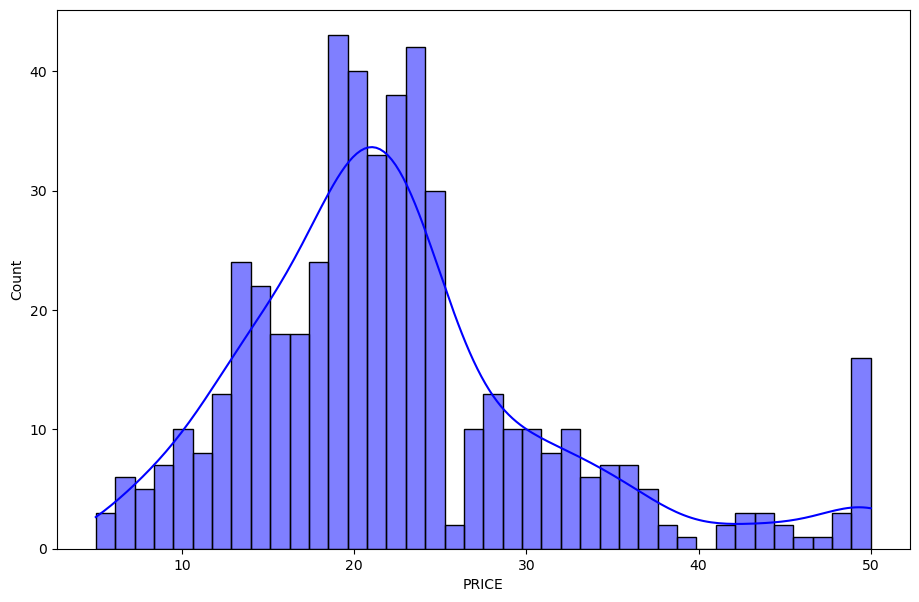

In [15]:
plt.figure(figsize=(11,7))
# sns.distplot(data["PRICE"], bins=40, hist=True, kde=True, color='blue')
sns.histplot(data["PRICE"], bins=40, kde=True, color='blue')
plt.show

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

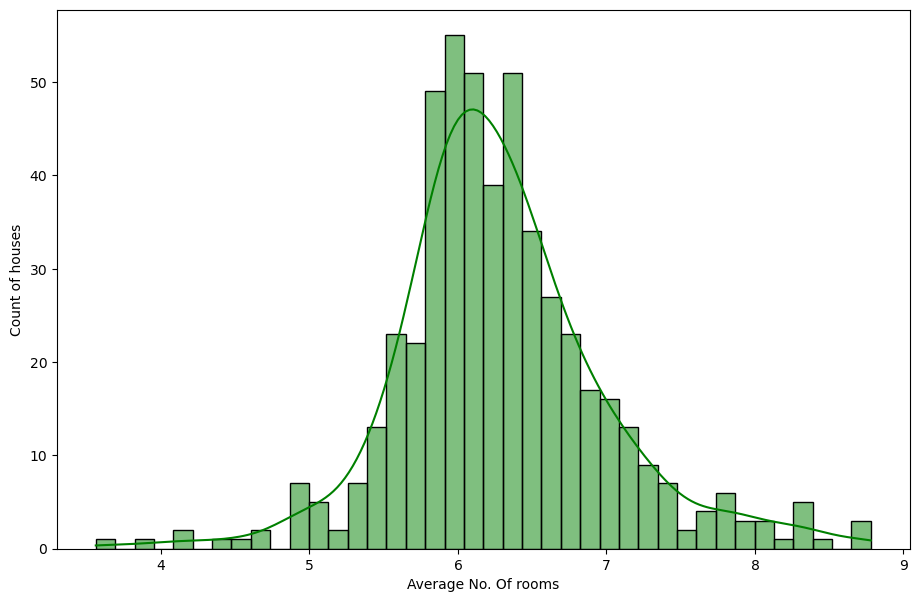

In [16]:
plt.figure(figsize=(11,7))
# sns.distplot(data["RM"], bins=40, hist=True, kde=True)
sns.histplot(data["RM"], bins=40, kde=True, color='green')
plt.ylabel("Count of houses")
plt.xlabel("Average No. Of rooms")
plt.show

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

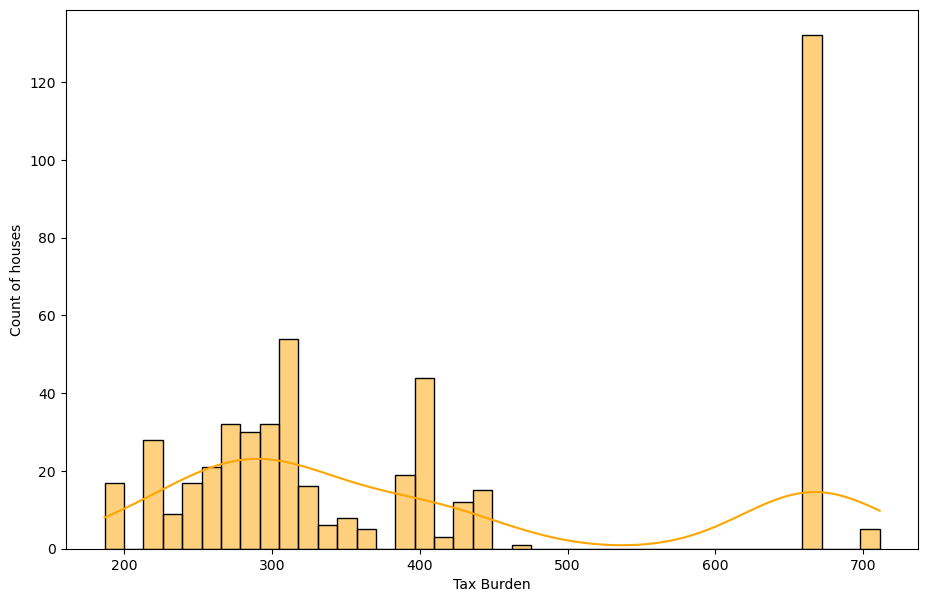

In [17]:
plt.figure(figsize=(11,7))
sns.histplot(data["TAX"], bins=40, kde=True, color='orange')
plt.ylabel("Count of houses")
plt.xlabel("Tax Burden")
plt.show

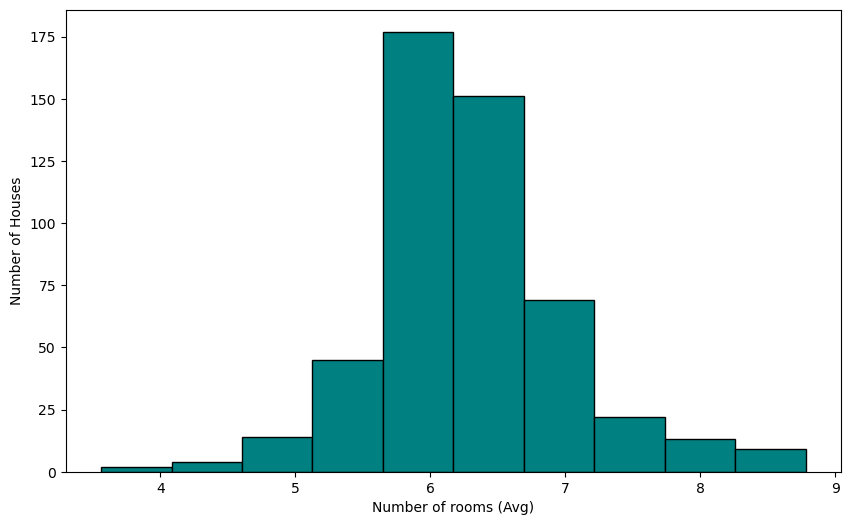

In [18]:
plt.figure(figsize=(10,6))
plt.hist(data["RM"], ec='black', color='Teal')
plt.xlabel("Number of rooms (Avg)")
plt.ylabel("Number of Houses")
plt.show()

In [19]:
mean_rooms = data["RM"].mean()
print(mean_rooms)

6.284634387351779


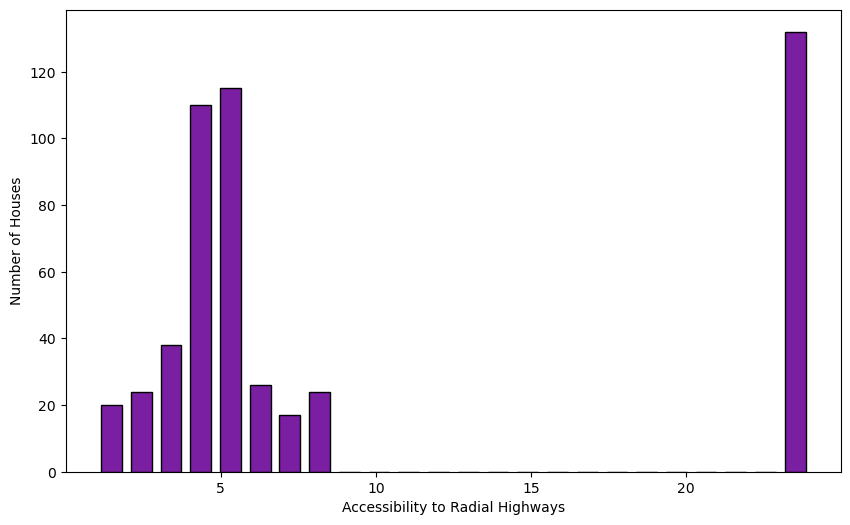

In [20]:
plt.figure(figsize=(10,6))
plt.hist(data["RAD"], bins = 24, ec='black', color='#7B1FA2', rwidth=0.7)
plt.xlabel("Accessibility to Radial Highways")
plt.ylabel("Number of Houses")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

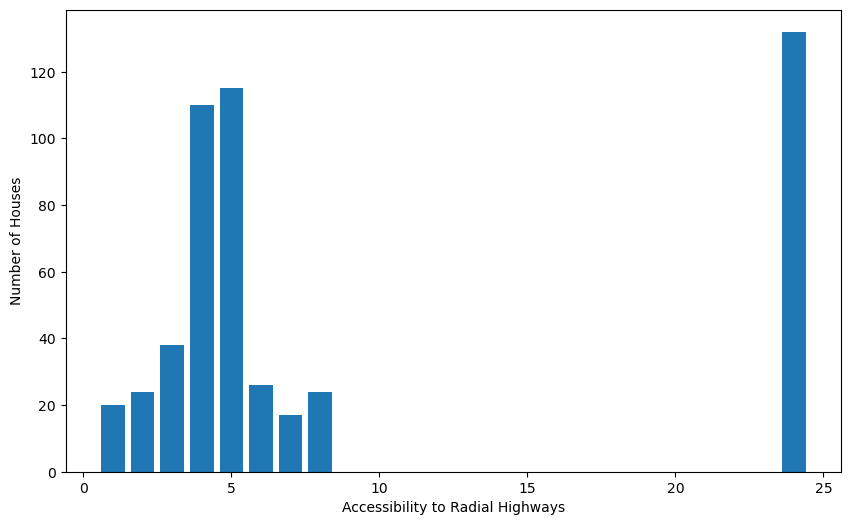

In [21]:
frequency = data["RAD"].value_counts()
# frequency.index
# frequency.axes[0]
plt.figure(figsize=(10,6))
plt.xlabel("Accessibility to Radial Highways")
plt.ylabel("Number of Houses")
plt.bar(frequency.index, height = frequency)
plt.show

In [22]:
data["CHAS"].value_counts()

CHAS
0.0    471
1.0     35
Name: count, dtype: int64

## Descriptive statistics

In [23]:
data["PRICE"].min()

5.0

In [24]:
data["PRICE"].max()

50.0

In [25]:
data.min()

CRIM         0.00632
ZN           0.00000
INDUS        0.46000
CHAS         0.00000
NOX          0.38500
RM           3.56100
AGE          2.90000
DIS          1.12960
RAD          1.00000
TAX        187.00000
PTRATIO     12.60000
B            0.32000
LSTAT        1.73000
PRICE        5.00000
dtype: float64

In [26]:
data.max()

CRIM        88.9762
ZN         100.0000
INDUS       27.7400
CHAS         1.0000
NOX          0.8710
RM           8.7800
AGE        100.0000
DIS         12.1265
RAD         24.0000
TAX        711.0000
PTRATIO     22.0000
B          396.9000
LSTAT       37.9700
PRICE       50.0000
dtype: float64

In [27]:
data.mean()

CRIM         3.613524
ZN          11.363636
INDUS       11.136779
CHAS         0.069170
NOX          0.554695
RM           6.284634
AGE         68.574901
DIS          3.795043
RAD          9.549407
TAX        408.237154
PTRATIO     18.455534
B          356.674032
LSTAT       12.653063
PRICE       22.532806
dtype: float64

In [28]:
data.median()

CRIM         0.25651
ZN           0.00000
INDUS        9.69000
CHAS         0.00000
NOX          0.53800
RM           6.20850
AGE         77.50000
DIS          3.20745
RAD          5.00000
TAX        330.00000
PTRATIO     19.05000
B          391.44000
LSTAT       11.36000
PRICE       21.20000
dtype: float64

In [29]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Correlation
## $$ \rho _{XY} = corr(X,Y)$$
## $$ -1.0 \leq \rho_{XY} \leq +1.0$$ 

In [30]:
#Correlation b/w rooms and price
data['PRICE'].corr(data['RM'])

0.6953599470715393

In [31]:
#Correlation b/w Student-Teacher ratio and price
data['PRICE'].corr(data['PTRATIO'])

-0.5077866855375621

In [32]:
data.corr() #Pearson Correlation coefficients

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


In [33]:
mask_app = np.zeros_like(data.corr())
triangle_indices = np.triu_indices_from(mask_app)
mask_app[triangle_indices] = True
mask_app

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

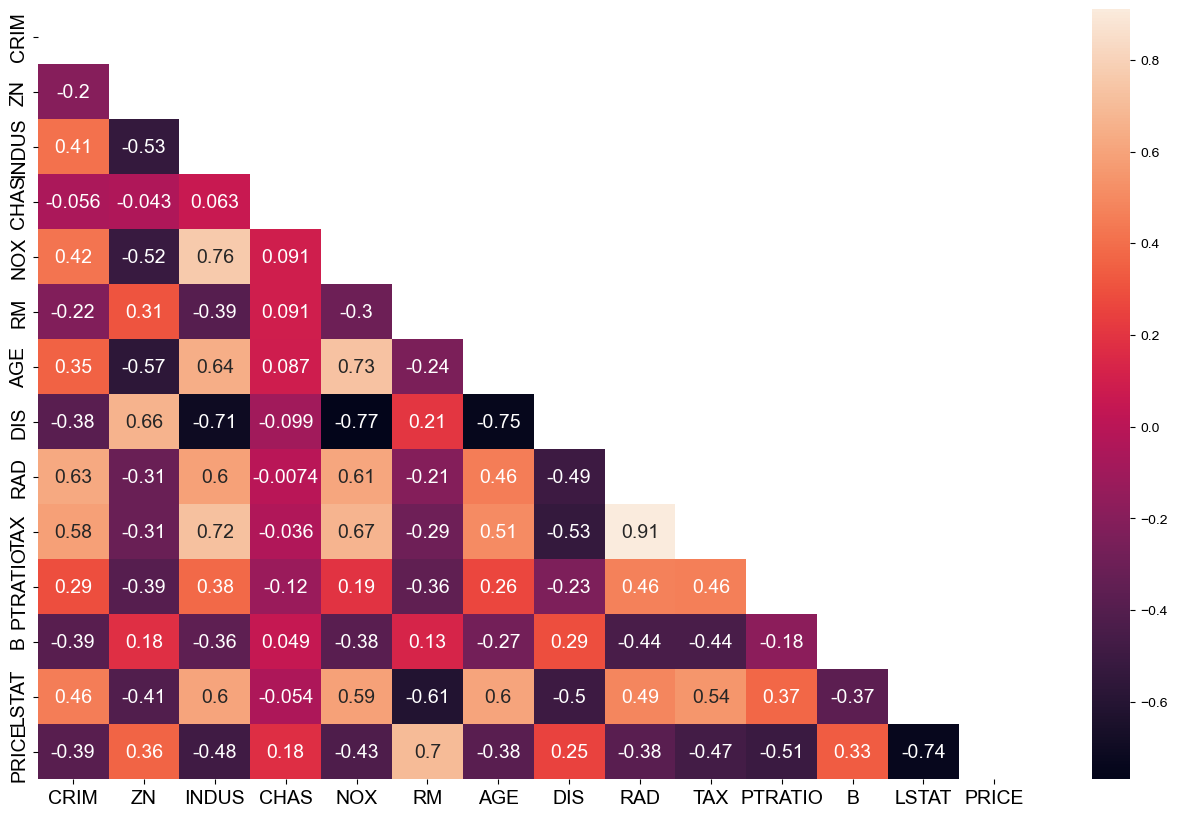

In [34]:
plt.figure(figsize = (16,10))
sns.heatmap(data.corr(), mask = mask_app, annot = True, annot_kws={"size": 14})
sns.set_style("white")
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

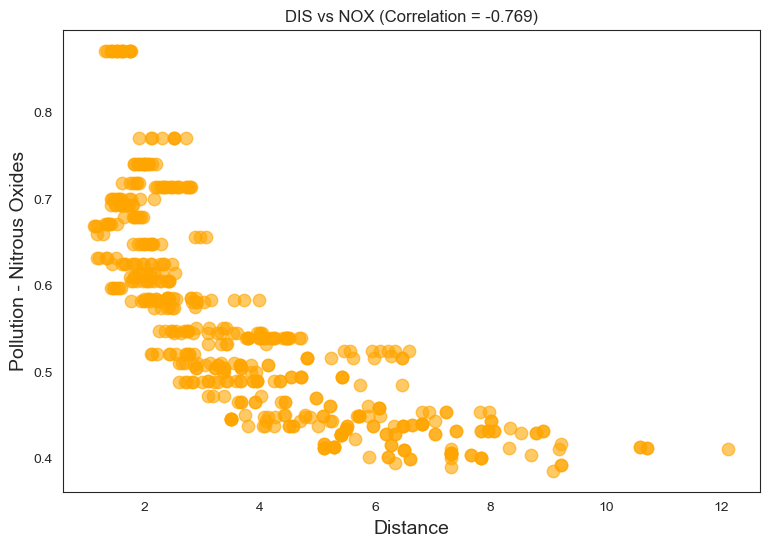

In [35]:
#Challenge: Visualise relation between Distance and pollution
nox_dis_corr = round(data['NOX'].corr(data['DIS']),3)
plt.figure(figsize = (9,6))
plt.title(f'DIS vs NOX (Correlation = {nox_dis_corr})')
plt.xlabel("Distance", fontsize=14)
plt.ylabel("Pollution - Nitrous Oxides", fontsize=14)
plt.scatter(x=data['DIS'], y=data['NOX'], alpha=0.6, s=80, color='orange')
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


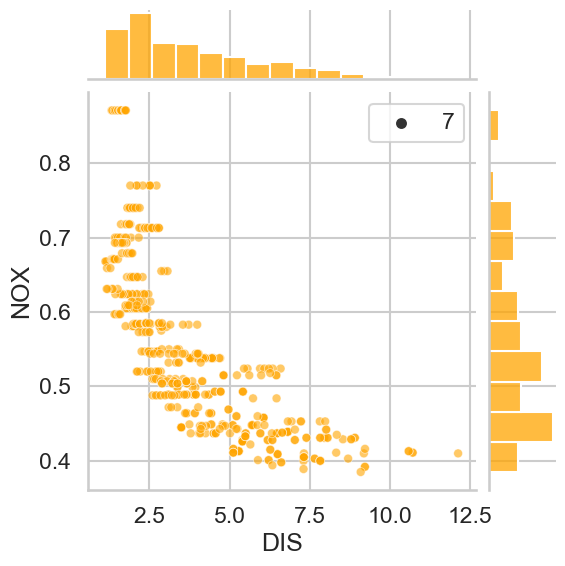

In [36]:
sns.set()
sns.set_context('talk')
sns.set_style('whitegrid')
sns.jointplot(x=data['DIS'], y=data['NOX'], size = 7, color='orange', joint_kws={'alpha':0.6})
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


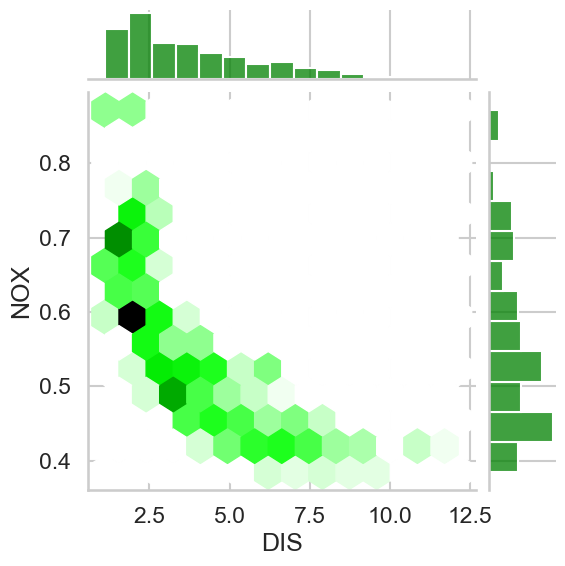

In [37]:
sns.set()
sns.set_context('talk')
sns.set_style('whitegrid')
sns.jointplot(x=data['DIS'], y=data['NOX'], color='green', kind='hex')
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


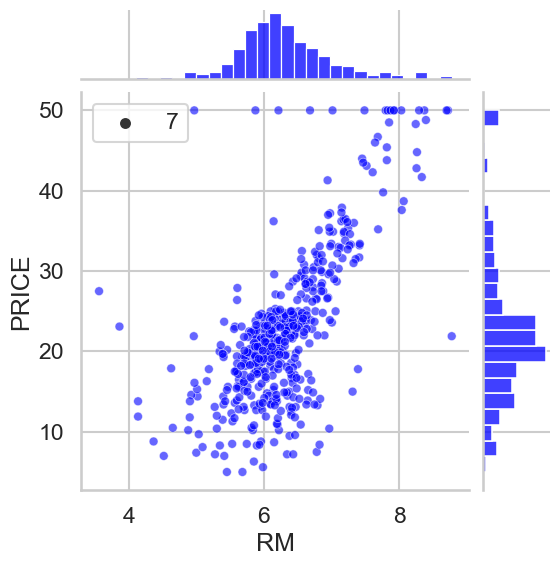

In [38]:
sns.set()
sns.set_context('talk')
sns.set_style('whitegrid')
sns.jointplot(x=data['RM'], y=data['PRICE'], size = 7, color='blue', joint_kws={'alpha':0.6})
plt.show()

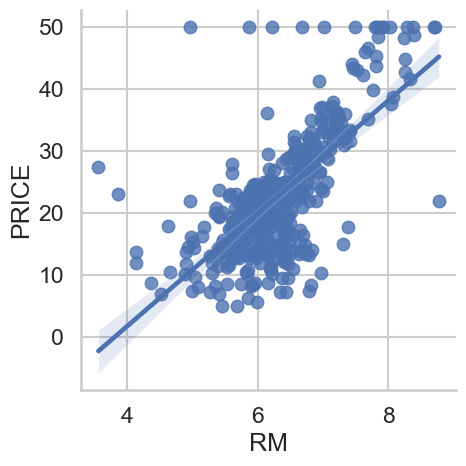

In [39]:
sns.lmplot(x='RM', y='PRICE', data=data)
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

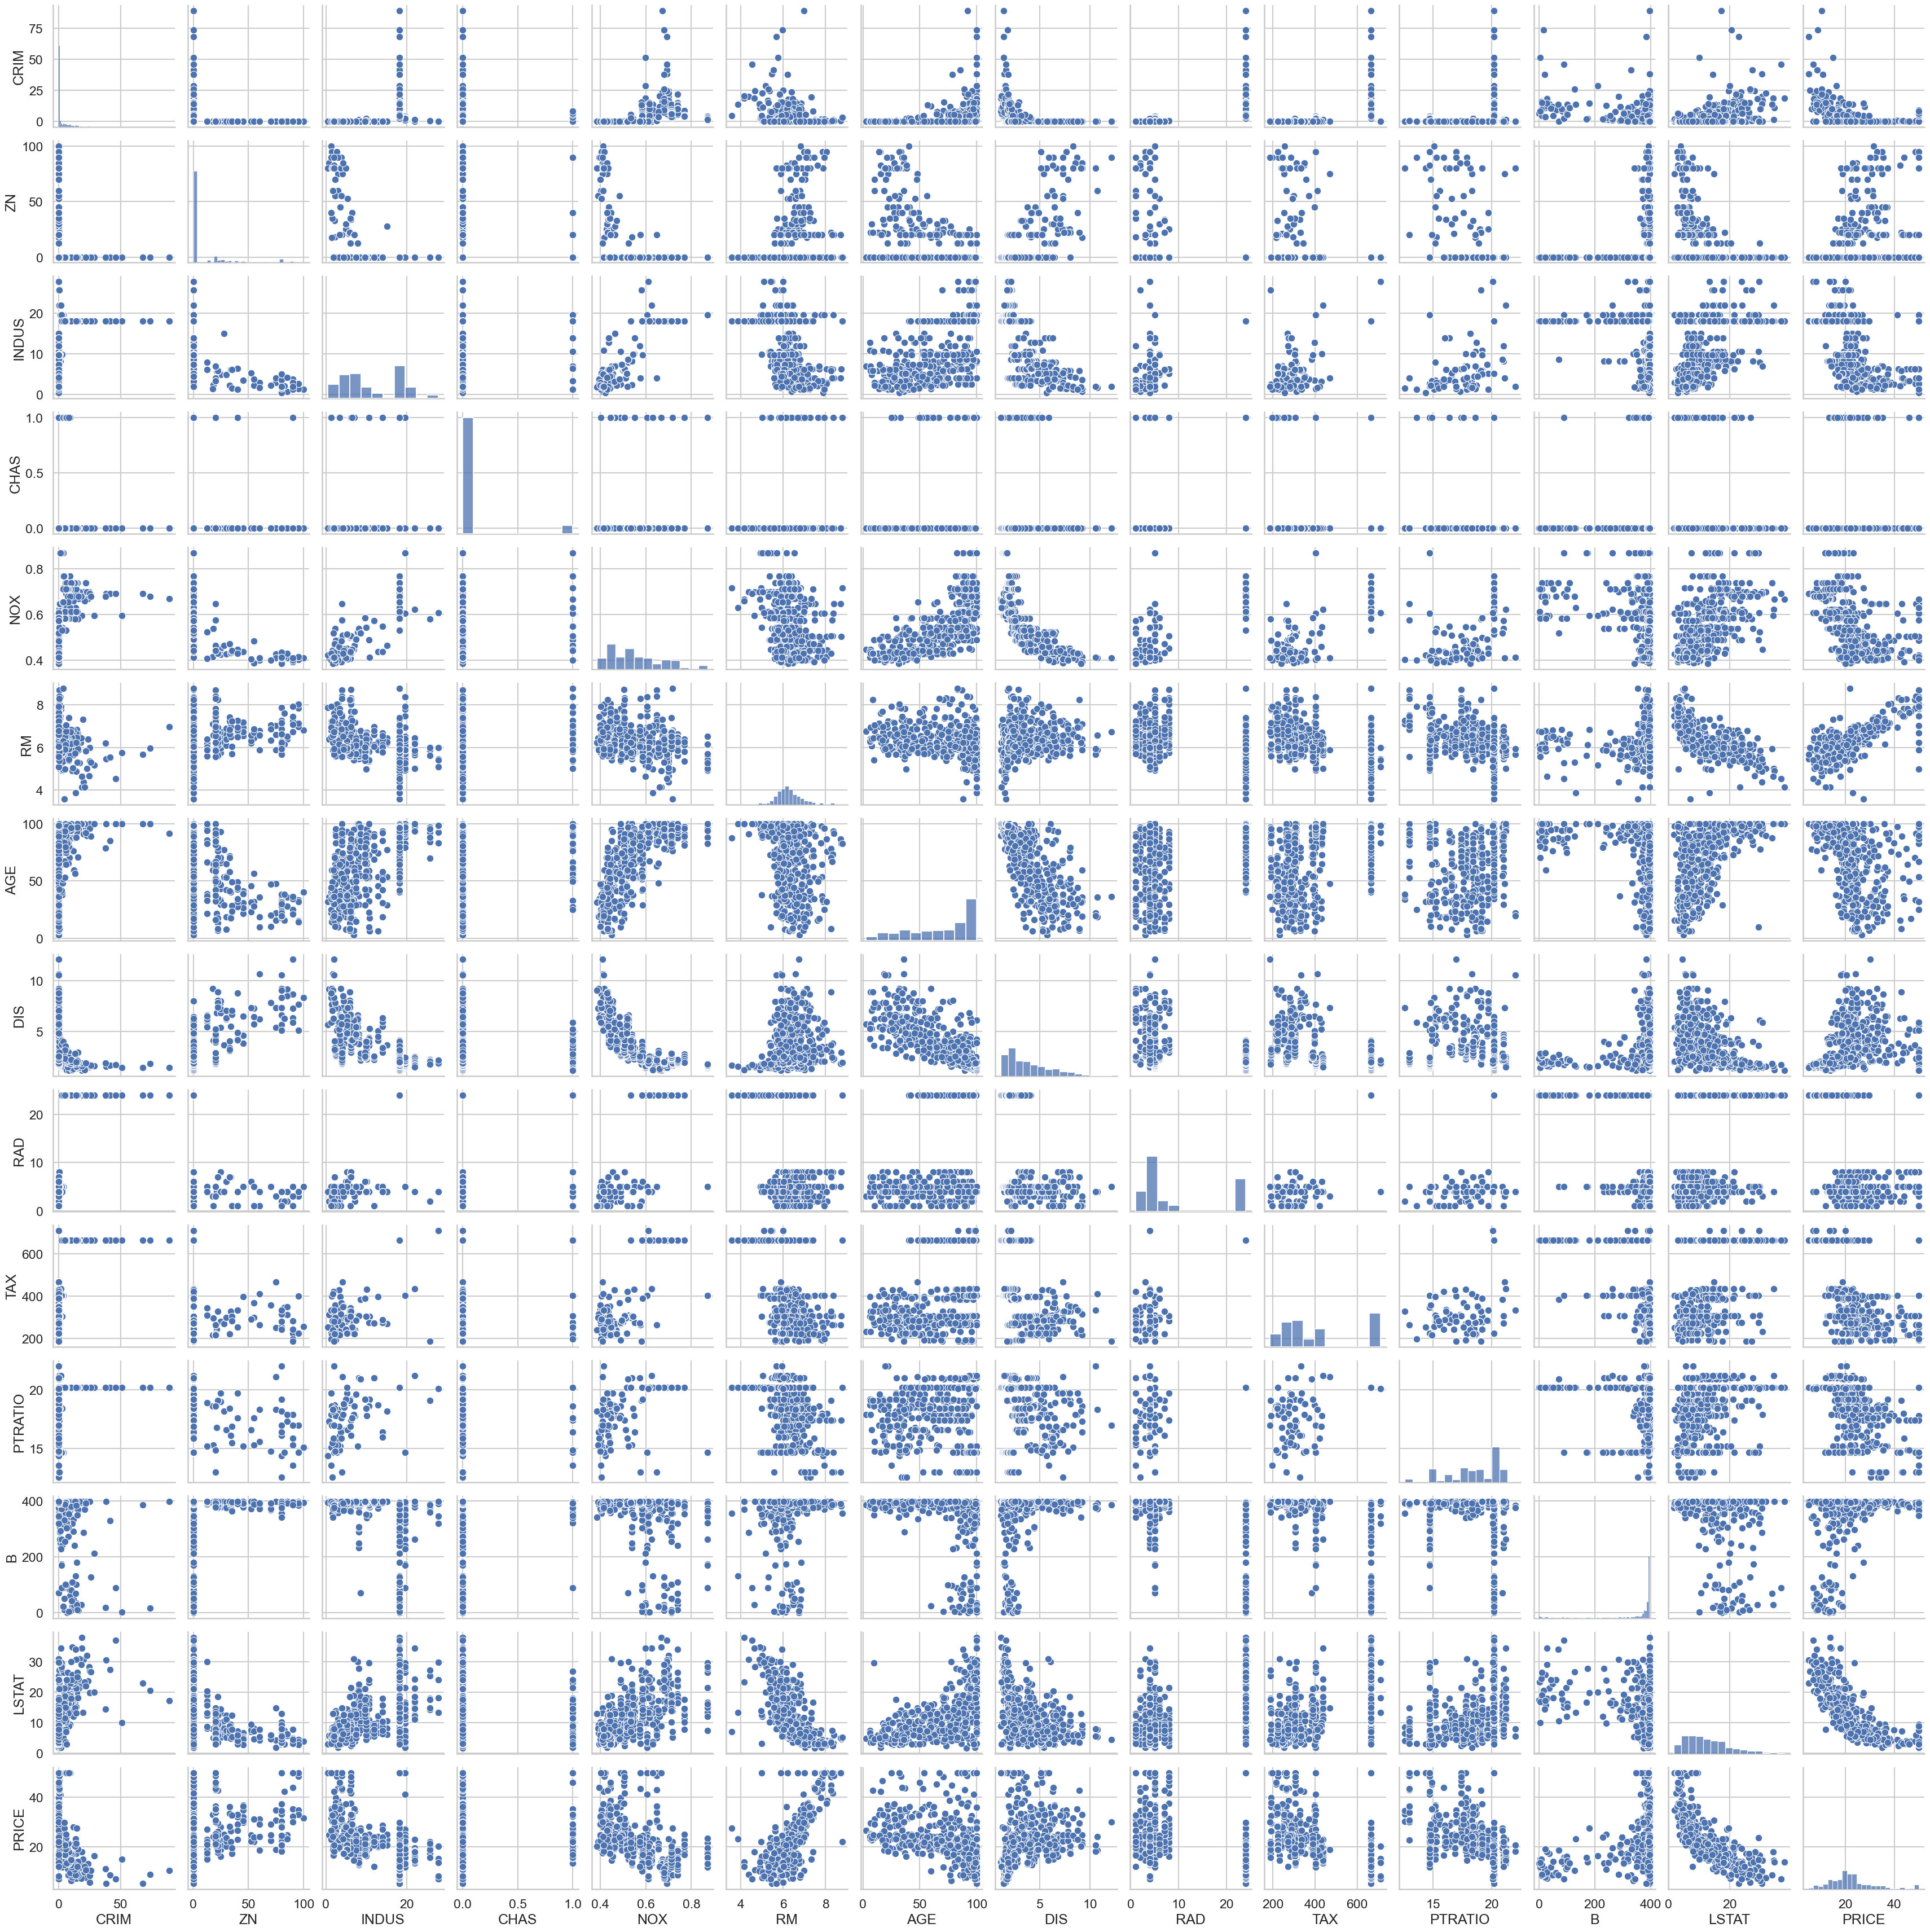

CPU times: total: 28.5 s
Wall time: 31.8 s


In [40]:
%%time
sns.pairplot(data)
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

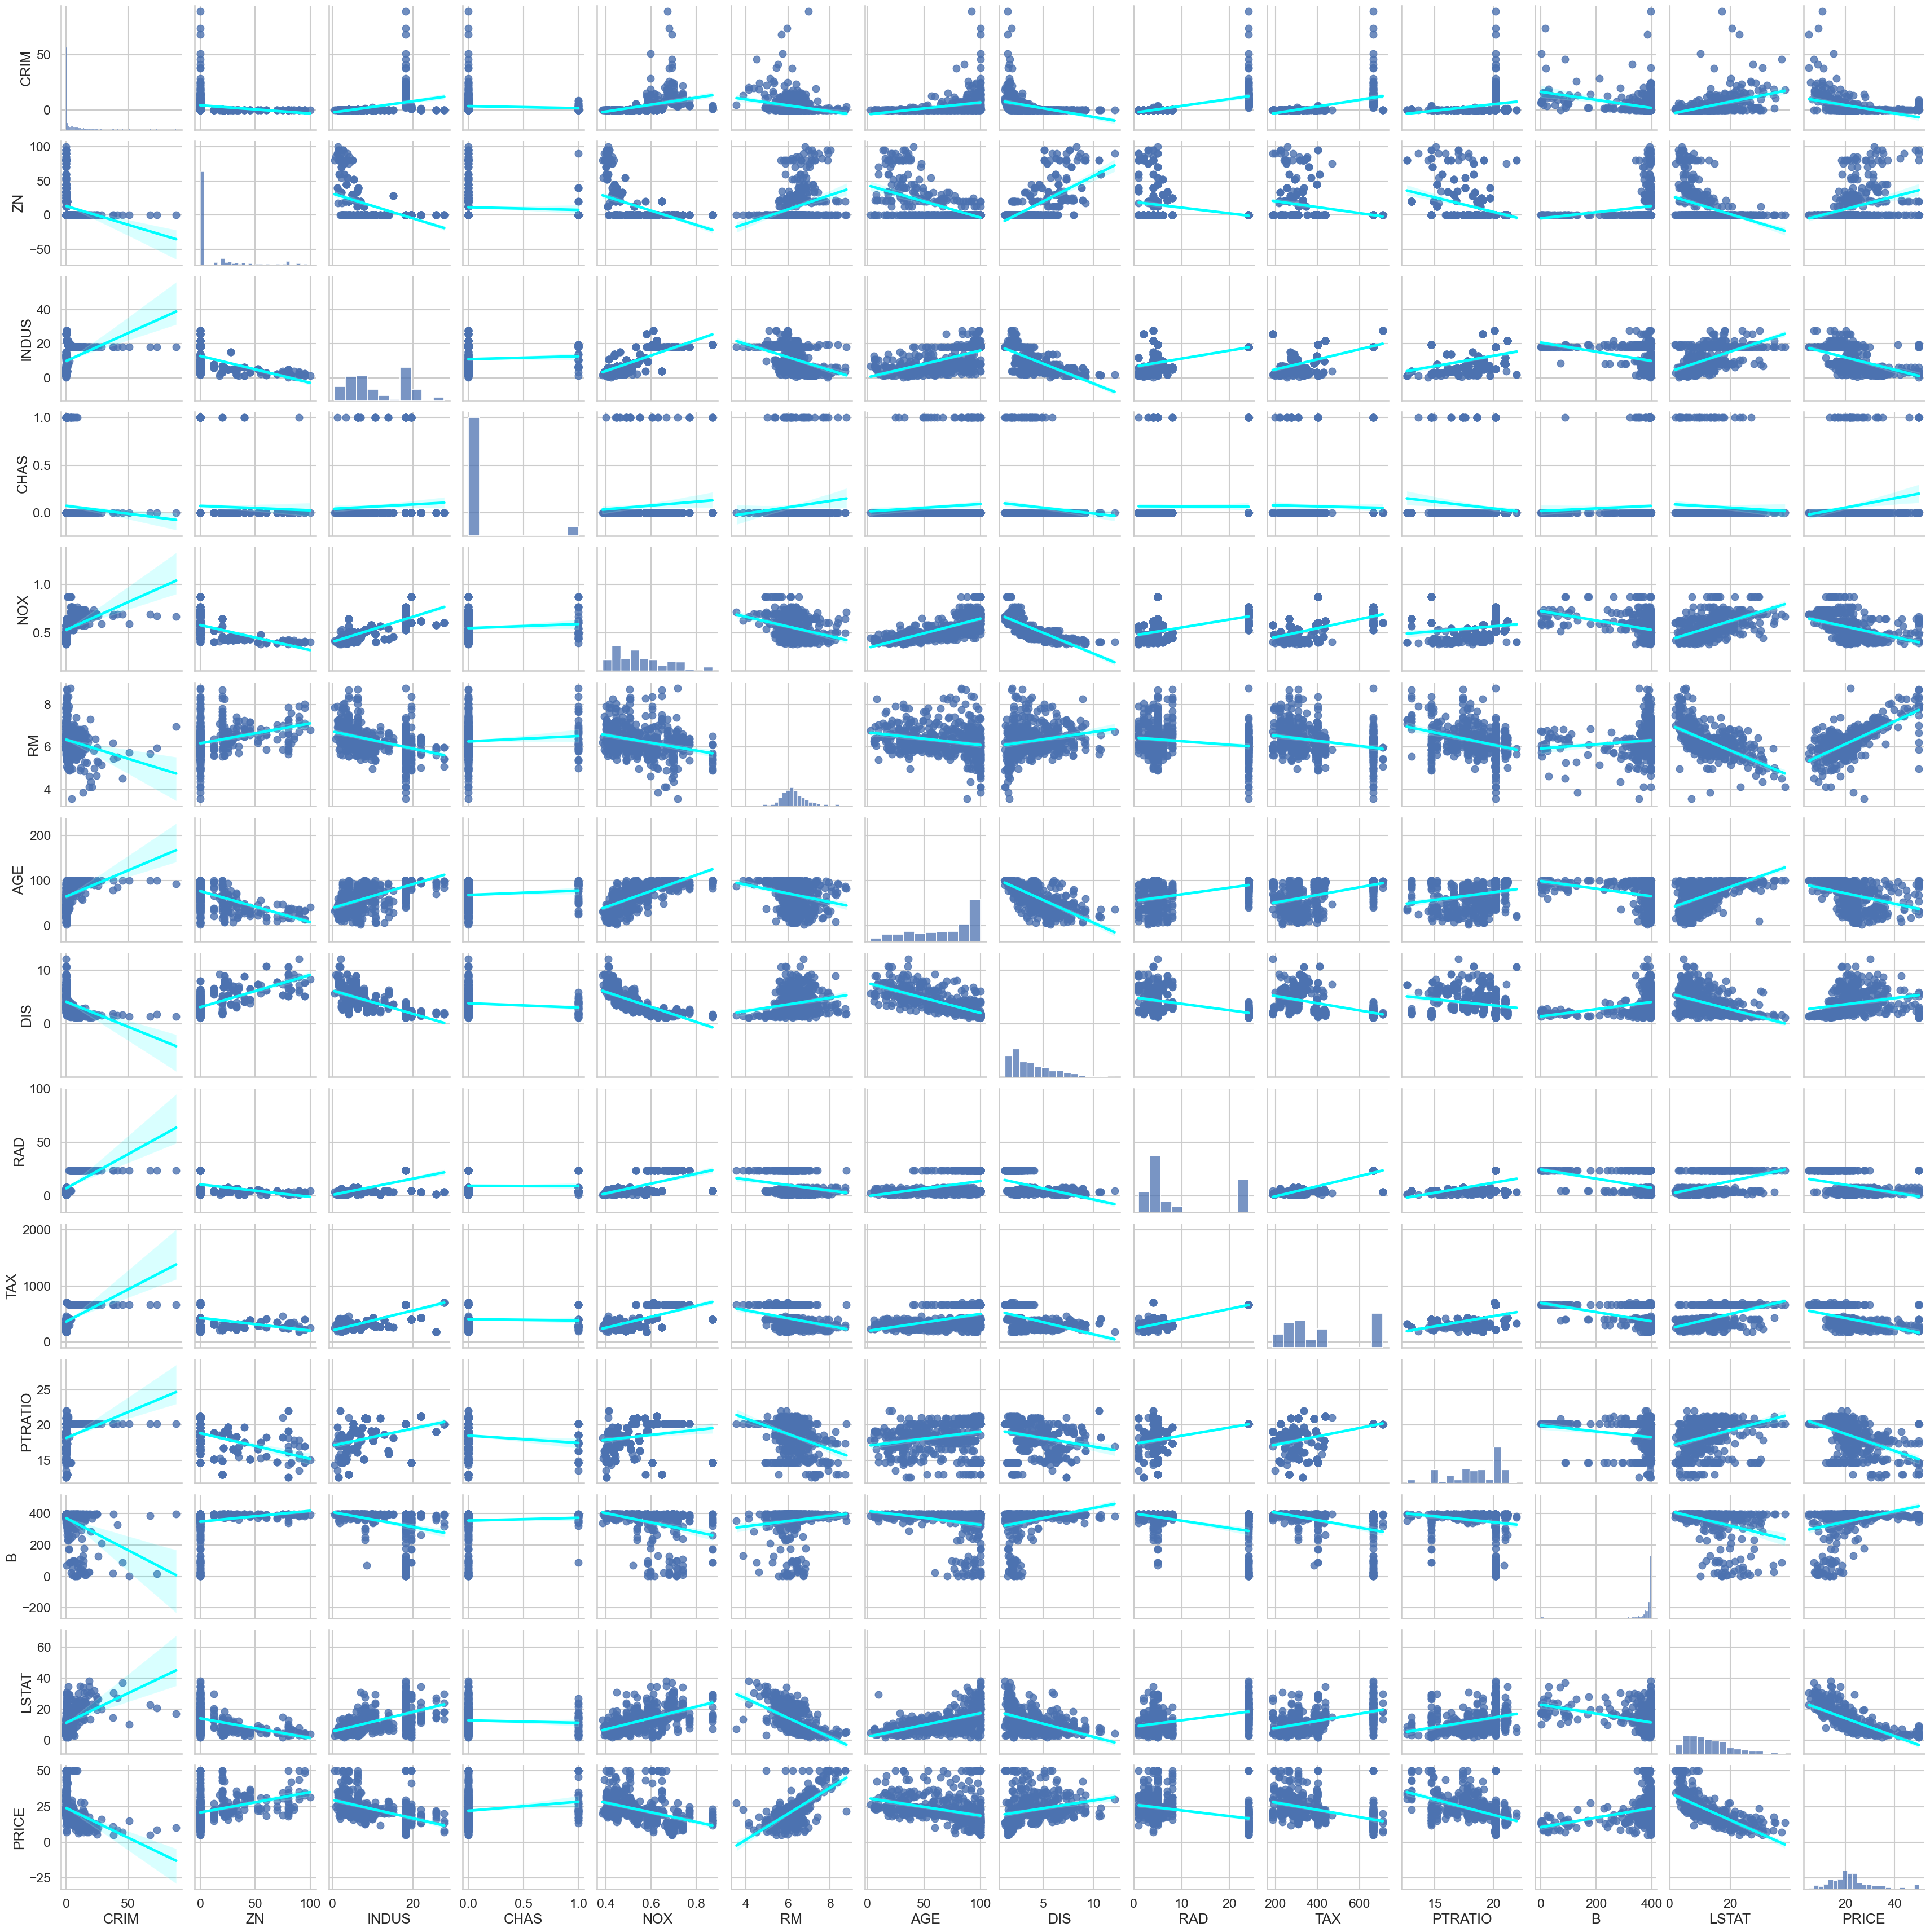

CPU times: total: 2min 22s
Wall time: 50 s


In [41]:
%%time
sns.pairplot(data, kind='reg', plot_kws={'line_kws':{'color':'cyan'}})
plt.show()

## Training & Test Dataset Split

In [42]:
prices = data['PRICE']
features = data.drop('PRICE', axis=1)

X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size = 0.2, random_state = 10)

# % of training set
len(X_train)/len(features)

# % of test set
len(X_test)/len(features)

0.2015810276679842

## Multivariate Regression

In [43]:
regr = LinearRegression()
regr.fit(X_train, y_train)

print('Intercept', regr.intercept_)
pd.DataFrame(data=regr.coef_, index=X_train.columns, columns=['coef'])

Intercept 36.533051382824205


,coef
CRIM,-0.128181
ZN,0.063198
INDUS,-0.007576
CHAS,1.974515
NOX,-16.271989
RM,3.108456
AGE,0.016292
DIS,-1.483014
RAD,0.303988
TAX,-0.012082


In [44]:
print('R-Square Value - Training: ', regr.score(X_train, y_train))
print('R-Square Value - Test: ', regr.score(X_test, y_test))

R-Square Value - Training:  0.750121534530608
R-Square Value - Test:  0.6709339839115629


# Data Transformations

In [45]:
data['PRICE'].skew()

1.1080984082549072

In [46]:
y_log = np.log(data['PRICE'])
y_log.head()

0    3.178054
1    3.072693
2    3.546740
3    3.508556
4    3.589059
Name: PRICE, dtype: float64

In [47]:
y_log.skew()

-0.33032129530987864

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


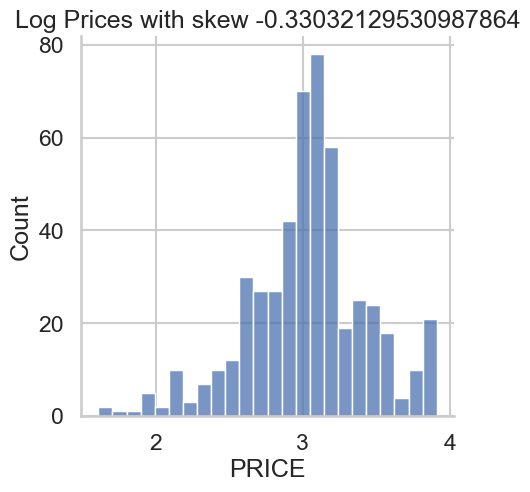

In [48]:
sns.displot(y_log)
plt.title(f'Log Prices with skew {y_log.skew()}')
plt.show()

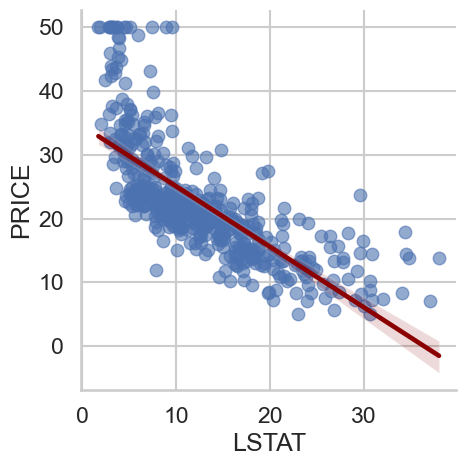

In [49]:
sns.lmplot(x='LSTAT', y='PRICE', data=data, scatter_kws={'alpha':0.6}, line_kws={'color': 'darkred'})
plt.show()

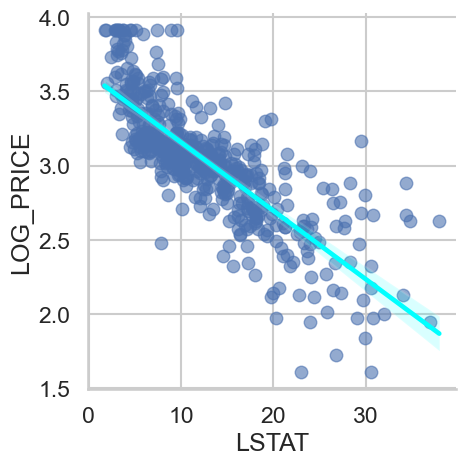

In [50]:
transformed_data = features
transformed_data['LOG_PRICE'] = y_log
sns.lmplot(x='LSTAT', y='LOG_PRICE', data=transformed_data, scatter_kws={'alpha':0.6}, line_kws={'color': 'cyan'})
plt.show()

## Regression using Log Prices

In [51]:
prices = np.log(data['PRICE'])
features = data.drop('PRICE', axis=1)

X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size = 0.2, random_state = 10)

# # % of training set
# len(X_train)/len(features)

# # % of test set
# len(X_test)/len(features)
regr = LinearRegression()
regr.fit(X_train, y_train)

print('Intercept', regr.intercept_)
pd.DataFrame(data=regr.coef_, index=X_train.columns, columns=['coef'])

Intercept 4.059943871775191


,coef
CRIM,-0.010672
ZN,0.001579
INDUS,0.002030
CHAS,0.080331
NOX,-0.704068
RM,0.073404
AGE,0.000763
DIS,-0.047633
RAD,0.014565
TAX,-0.000645


In [52]:
print('R-Square Value - Training: ', regr.score(X_train, y_train))
print('R-Square Value - Test: ', regr.score(X_test, y_test))

R-Square Value - Training:  0.7930234826697584
R-Square Value - Test:  0.7446922306260728


## P-Values and evaluating coefficients

In [53]:
X_incl_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()
# results.params
# results.pvalues

pd.DataFrame({'Coefficients': results.params, 'P-Values':round(results.pvalues, 3)})
# INDUS and AGE features are not significant

,Coefficients,P-Values
const,4.059944,0.000
CRIM,-0.010672,0.000
ZN,0.001579,0.009
INDUS,0.002030,0.445
CHAS,0.080331,0.038
NOX,-0.704068,0.000
RM,0.073404,0.000
AGE,0.000763,0.209
DIS,-0.047633,0.000
RAD,0.014565,0.000


## Testing for Multicollinearity
$$ TAX = \alpha_0 + \alpha_1 RM + \alpha_2 NOX + ..... + \alpha_{12}LSTAT $$
$$ VIF _{TAX} = \frac{1}{(1-R_{TAX} ^ 2)} $$

In [54]:
# VIF for Crime
variance_inflation_factor(exog=X_incl_const.values, exog_idx=1)

1.7145250443932485

In [55]:
# len(X_incl_const.columns)
# X_incl_const.shape[1]
list(X_incl_const.columns)

['const',
 'CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

$$ VIF_{limit}: 10 $$

In [56]:
# VIF for all variables
VIF = [variance_inflation_factor(exog=X_incl_const, exog_idx=n) for n in range(len(X_incl_const.columns))]
VIF = pd.DataFrame({'Factors': X_incl_const.columns, 'VIF': np.around(VIF,2)})
VIF

,Factors,VIF
0,const,597.55
1,CRIM,1.71
2,ZN,2.33
3,INDUS,3.94
4,CHAS,1.08
5,NOX,4.41
6,RM,1.84
7,AGE,3.33
8,DIS,4.22
9,RAD,7.31


## Model simplification & BIC

In [57]:
#Original model with log prices & all features
X_incl_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()
# results.params
# results.pvalues

org_coeff = pd.DataFrame({'Coefficients': results.params, 'P-Values':round(results.pvalues, 3)})
print("BIC of the model: ", round(results.bic,3))
print("R-Square of the model: ", round(results.rsquared, 3))

BIC of the model:  -139.75
R-Square of the model:  0.793


In [58]:
#New model with log prices & INDUS feature dropped
X_incl_const = sm.add_constant(X_train)
X_incl_const = X_incl_const.drop(['INDUS'], axis=1)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()
# results.params
# results.pvalues

new_coeff = pd.DataFrame({'Coefficients': results.params, 'P-Values':round(results.pvalues, 3)})
print("BIC of the model: ", round(results.bic,3))
print("R-Square of the model: ", round(results.rsquared, 3))

BIC of the model:  -145.145
R-Square of the model:  0.793


In [59]:
#New model with log prices & INDUS and AGE features dropped
X_incl_const = sm.add_constant(X_train)
X_incl_const = X_incl_const.drop(['INDUS', 'AGE'], axis=1)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()
# results.params
# results.pvalues

new_coeff_2 = pd.DataFrame({'Coefficients': results.params, 'P-Values':round(results.pvalues, 3)})
print("BIC of the model: ", round(results.bic,3))
print("R-Square of the model: ", round(results.rsquared, 3))

BIC of the model:  -149.499
R-Square of the model:  0.792


In [60]:
frames = [org_coeff, new_coeff, new_coeff_2]
pd.concat(frames, axis=1)

,Coefficients,P-Values,Coefficients,P-Values,Coefficients,P-Values
const,4.059944,0.000,4.056231,0.000,4.035922,0.000
CRIM,-0.010672,0.000,-0.010721,0.000,-0.010702,0.000
ZN,0.001579,0.009,0.001551,0.010,0.001461,0.014
INDUS,0.002030,0.445,NaN,NaN,NaN,NaN
CHAS,0.080331,0.038,0.082795,0.032,0.086449,0.025
NOX,-0.704068,0.000,-0.673365,0.000,-0.616448,0.000
RM,0.073404,0.000,0.071739,0.000,0.076133,0.000
AGE,0.000763,0.209,0.000766,0.207,NaN,NaN
DIS,-0.047633,0.000,-0.049394,0.000,-0.052692,0.000
RAD,0.014565,0.000,0.014014,0.000,0.013743,0.000


## Residuals and Residual Plots

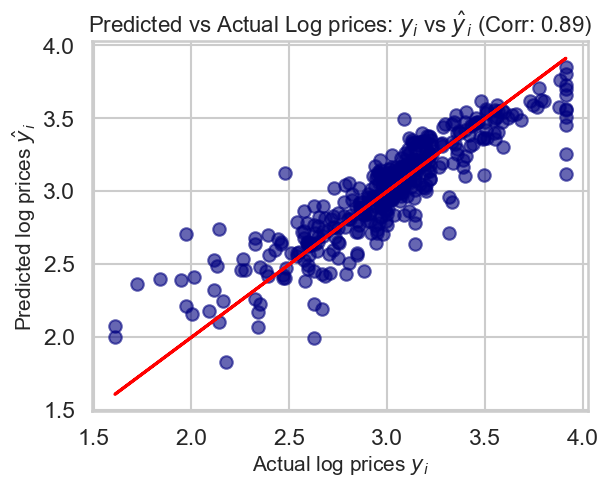

In [110]:
#Modified model: transformed (using log prices) & simplified (dropping two features)
prices = np.log(data['PRICE'])
features = data.drop(['PRICE', 'INDUS', 'AGE'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size = 0.2, random_state = 10)

# # % of training set
# len(X_train)/len(features)
#Using StatsModel
X_incl_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()

#Residuals
# residuals = y_train - results.fittedvalues
# residuals.describe()
# results.resid

#Graph of actual vs predicted house prices
corr = round(y_train.corr(results.fittedvalues),2)
plt.scatter(x=y_train, y=results.fittedvalues, c='navy', alpha=0.6)
plt.plot(y_train, y_train, c='red')
plt.xlabel('Actual log prices $y_i$', fontsize = 15)
plt.ylabel('Predicted log prices $\hat y_i$', fontsize = 15)
plt.title(f"Predicted vs Actual Log prices: $y_i$ vs $\hat y_i$ (Corr: {corr})", fontsize = 16)
plt.show()

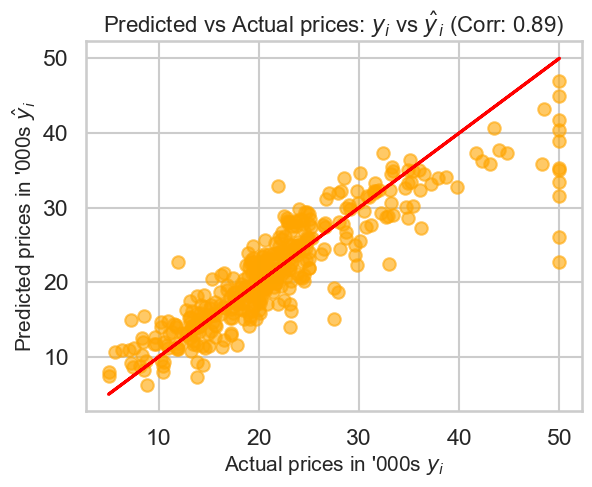

In [111]:
plt.scatter(x=np.e**y_train, y=np.e**results.fittedvalues, c='orange', alpha=0.6)
plt.plot(np.e**y_train, np.e**y_train, c='red')
plt.xlabel('Actual prices in \'000s $y_i$', fontsize = 15)
plt.ylabel('Predicted prices in \'000s $\hat y_i$', fontsize = 15)
plt.title(f"Predicted vs Actual prices: $y_i$ vs $\hat y_i$ (Corr: {corr})", fontsize = 16)
plt.show()

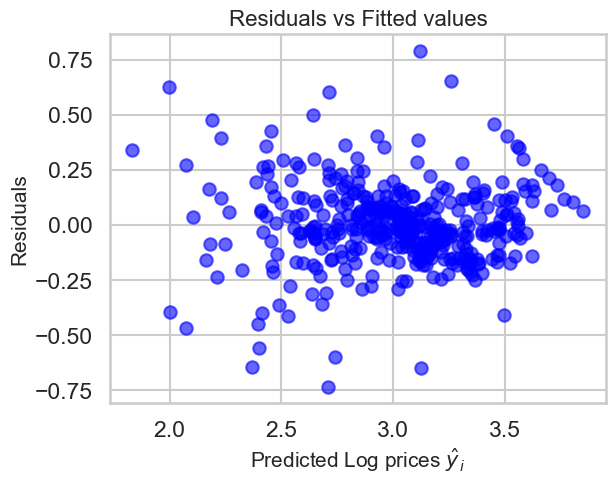

In [112]:
# Residuals vs Predicted values
plt.scatter(x=results.fittedvalues, y=results.resid, c='blue', alpha=0.6)
plt.xlabel('Predicted Log prices $\hat y_i$', fontsize = 15)
plt.ylabel('Residuals', fontsize = 15)
plt.title(f"Residuals vs Fitted values", fontsize = 16)
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


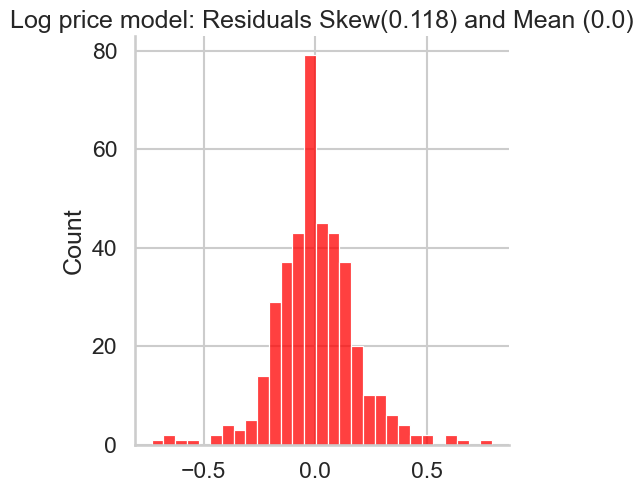

In [113]:
#Distribution of residuals (log Prices) - checking for normality
resid_mean = round(results.resid.mean(),3)
resid_skew = round(results.resid.skew(),3)

sns.displot(results.resid, color='red')
plt.title(f'Log price model: Residuals Skew({resid_skew}) and Mean ({resid_mean})')
plt.show()

In [114]:
#Mean squared error & R-squared:
reduced_log_mse = round(results.mse_resid,3)
reduced_log_rsquared = round(results.rsquared,3)

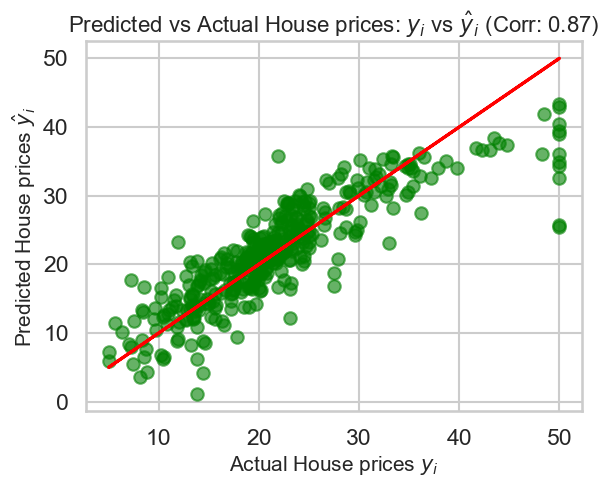

In [115]:
#Original model:
prices = data['PRICE']
features = data.drop('PRICE', axis=1)

X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size = 0.2, random_state = 10)

# # % of training set
# len(X_train)/len(features)
#Using StatsModel
X_incl_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()

#Residuals
# residuals = y_train - results.fittedvalues
# residuals.describe()
# results.resid

#Graph of actual vs predicted house prices
corr = round(y_train.corr(results.fittedvalues),2)
plt.scatter(x=y_train, y=results.fittedvalues, c='green', alpha=0.6)
plt.plot(y_train, y_train, c='red')
plt.xlabel('Actual House prices $y_i$', fontsize = 15)
plt.ylabel('Predicted House prices $\hat y_i$', fontsize = 15)
plt.title(f"Predicted vs Actual House prices: $y_i$ vs $\hat y_i$ (Corr: {corr})", fontsize = 16)
plt.show()

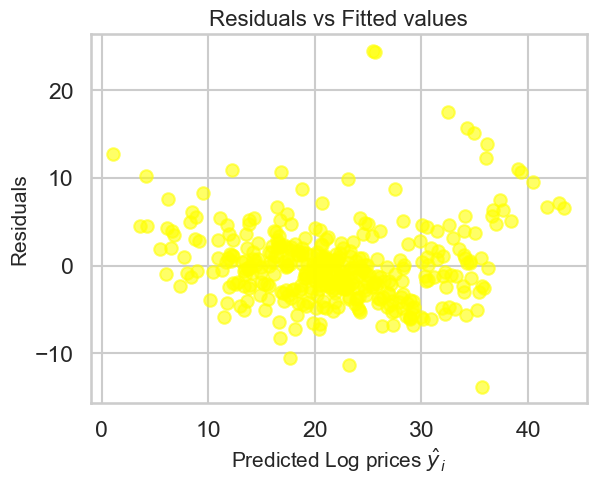

In [116]:
# Residuals vs Predicted values
plt.scatter(x=results.fittedvalues, y=results.resid, c='yellow', alpha=0.6)
plt.xlabel('Predicted Log prices $\hat y_i$', fontsize = 15)
plt.ylabel('Residuals', fontsize = 15)
plt.title(f"Residuals vs Fitted values", fontsize = 16)
plt.show()

C:\Users\ryan6\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


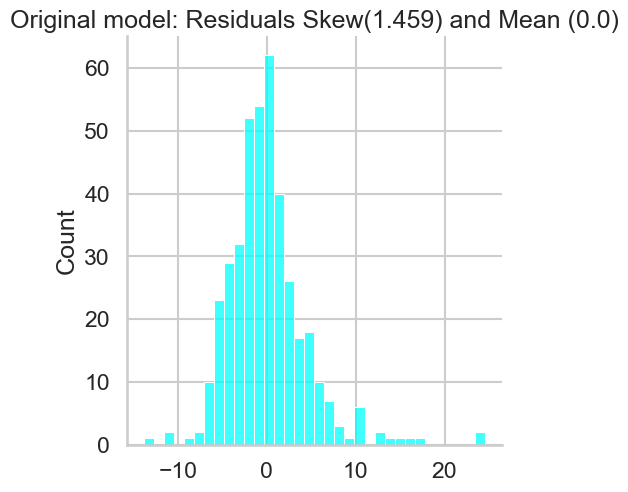

In [117]:
#Distribution of residuals (Original) - checking for normality
resid_mean = round(results.resid.mean(),3)
resid_skew = round(results.resid.skew(),3)

sns.displot(results.resid, color='cyan')
plt.title(f'Original model: Residuals Skew({resid_skew}) and Mean ({resid_mean})')
plt.show()

In [118]:
#Mean squared error & R-squared:
full_normal_mse = round(results.mse_resid,3)
full_normal_rsquared = round(results.rsquared, 3)

In [120]:
pd.DataFrame({'R-Squared':[reduced_log_rsquared, full_normal_rsquared],
             'MSE':[reduced_log_mse, full_normal_mse],
             'RMSE':[reduced_log_mse**(1/2), full_normal_mse**(1/2)]}, index=['Reduced Log model', 'Full Normal model'])

,R-Squared,MSE,RMSE
Reduced Log model,0.792,0.035,0.187083
Full Normal model,0.750,19.921,4.463295


In [123]:
print('2 SD in log prices is', 2*np.sqrt(reduced_log_mse))

upper_bound = np.log(30) + 2*np.sqrt(reduced_log_mse)
print('The upper bound in log prices for a 95% Prediction interval is: ', upper_bound)
print('The upper bound in dollar prices is: $', np.e**upper_bound * 1000)

lower_bound = np.log(30) - 2*np.sqrt(reduced_log_mse)
print('The lower bound in log prices for a 95% Prediction interval is: ', lower_bound)
print('The lower bound in dollar prices is: $', np.e**lower_bound * 1000)

2 SD in log prices is 0.37416573867739417
The upper bound in log prices for a 95% Prediction interval is:  3.7753631203395495
The upper bound in dollar prices is: $ 43613.34233239937
The lower bound in log prices for a 95% Prediction interval is:  3.0270316429847615
The lower bound in dollar prices is: $ 20635.886906824155


In [124]:
import Boston_Valuation as val
val.get_dollar_estimate(8,15,0.0)

The Estimated property value is $755000.0
At 95% confidence level, the valuation range is
$519000.0 at the lower end and $1099000.0 at the higher end.


C:\Users\ryan6\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(
C:\Users\ryan6\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
